# Lecture 2 — Practical: *Building and Evaluating Your First Baseline*
### Practical Machine Learning for Transcriptomics in Cancer Research

This is the first **modelling** practical. You take the clean, split METABRIC data from Lecture 1
and build a complete, *trustworthy* baseline:

1. preprocess **inside a pipeline** (fit on train only),
2. train a **regularised Logistic Regression**,
3. evaluate with **imbalance-aware metrics** (precision, recall, F1, ROC-AUC, PR-AUC),
4. **cross-validate honestly** (the whole pipeline inside every fold),
5. diagnose **overfitting** (train vs test, and a regularisation sweep),
6. **interpret** coefficients as biological *hypotheses*,
7. write a short **baseline model report** — the assessable deliverable.

> **The model is the easy part.** As in the lecture, the classifier takes a few lines; the value is
> in doing the pipeline, the evaluation, and the overfitting check *trustworthily*. Adopt the mindset
> of an analyst writing the "baseline model" section of a methods paper — building a defensible
> yardstick, not chasing a number.

#### Continuity & reminders
- **Label:** binary **recurrence** (relapse within the horizon) — *not* pCR. A deliberate
  simplification of time-to-event data (revisited in Section 5 of the course).
- **Class imbalance:** recurrence is the minority class → accuracy will mislead; stratify everything.
- **Leakage discipline (Lecture 1):** every data-dependent step is fit on **training data only**.

> **Network note.** This notebook reuses Lecture 1's real-data loaders (cBioPortal + GEO). If the
> prepared Lecture 1 artefacts are present in the shared `datasets/` cache they are loaded directly;
> otherwise they are regenerated (needs internet). Downloads are git-ignored.


## Section 0 — Setup & framing  *(≈10 min)*

In [1]:
import sys, subprocess
def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
try:
    import GEOparse  # noqa
except ImportError:
    _pip("GEOparse")

import os, tarfile, io, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, accuracy_score)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

def _resolve_data_dir():
    """Find the shared lesson-01 datasets/ cache regardless of where Jupyter launched,
    so this Lecture-2 notebook reuses the data Lecture 1 already downloaded."""
    here = Path.cwd()
    for parent in [here, *here.parents]:
        lessons = parent / "lessons"
        if lessons.is_dir():
            for cand in sorted(lessons.glob("lesson01_*/practical/task/datasets")):
                cand.mkdir(parents=True, exist_ok=True); return cand
            for cand in sorted(lessons.glob("lesson01_*/practical/task")):
                d = cand / "datasets"; d.mkdir(parents=True, exist_ok=True); return d
    for c in [here.parent / "datasets", here / "datasets"]:
        if c.parent.exists():
            c.mkdir(parents=True, exist_ok=True); return c
    fb = here / "datasets"; fb.mkdir(parents=True, exist_ok=True); return fb

DATA_DIR = str(_resolve_data_dir())
print("Setup complete. Shared data cache:")
print("  ", os.path.abspath(DATA_DIR))

Setup complete. Shared data cache:
   /beegfs/scratch/ieo7993/projects/ml26/lessons/lesson01_biological_question/practical/task/datasets


### Loading the prepared Lecture 1 cohort (shared infrastructure)

The cell below reuses Lecture 1's real loaders and rebuilds the prepared starting point: the
HR+/HER2− expression matrix, the binary recurrence label, and a **patient-level, stratified**
train/validation/test split. Read it, but you don't need to edit it — today's teaching happens
*after* this point. (If you saved Lecture 1's artefacts, you could load them instead; we regenerate
here so the notebook is self-contained.)


In [2]:
# cBioPortal now serves brca_metabric as individual git-LFS files (the old S3
# tarball URL returns 403). Fetch the three files we need and cache them; this
# reuses the SAME cache files as the Lecture 1 practical.
CBIO_BASE = ("https://media.githubusercontent.com/media/cBioPortal/datahub/"
             "master/public/brca_metabric")
CBIO_FILES = {"expr":    "data_mrna_illumina_microarray.txt",   # large (~660 MB)
              "patient": "data_clinical_patient.txt",
              "sample":  "data_clinical_sample.txt"}

def _download(url, dest):
    if os.path.exists(dest) and os.path.getsize(dest) > 0:
        return dest
    print(f"Downloading {os.path.basename(dest)} ...")
    r = requests.get(url, stream=True, timeout=300, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    with open(dest, "wb") as fh:
        for chunk in r.iter_content(chunk_size=1 << 20):
            fh.write(chunk)
    return dest

def _read_cbio_clinical(path):
    return pd.read_csv(path, sep="\t", comment="#", low_memory=False)

def load_metabric(data_dir=DATA_DIR):
    paths = {k: _download(f"{CBIO_BASE}/{fn}", os.path.join(data_dir, fn))
             for k, fn in CBIO_FILES.items()}
    expr = pd.read_csv(paths["expr"], sep="\t", low_memory=False)
    expr = expr.drop(columns=[c for c in ["Entrez_Gene_Id"] if c in expr.columns])
    expr = expr.dropna(subset=["Hugo_Symbol"]).set_index("Hugo_Symbol")
    expr = expr[~expr.index.duplicated(keep="first")]
    pat = _read_cbio_clinical(paths["patient"])
    smp = _read_cbio_clinical(paths["sample"])
    clin = pat.merge(smp, on="PATIENT_ID", how="inner", suffixes=("", "_smp"))
    if "SAMPLE_ID" in clin.columns:
        clin = clin.set_index("SAMPLE_ID")
    return expr, clin

def prepare_cohort():
    """Reproduce the Lecture 1 prepared cohort: HR+/HER2- , binary recurrence label,
    samples x genes matrix aligned to the label."""
    expr, clin = load_metabric()
    X = expr.T.copy(); X.index.name = "SAMPLE_ID"
    assert X.shape[1] > X.shape[0] and "ESR1" in X.columns, "orientation check failed"
    common = sorted(set(X.index) & set(clin.index))
    X, clin = X.loc[common], clin.loc[common]
    # HR+/HER2-
    hrpos = clin.get("ER_STATUS").eq("Positive") | clin.get("PR_STATUS").eq("Positive")
    her2neg = clin.get("HER2_STATUS").eq("Negative")
    mask = (hrpos & her2neg).fillna(False)
    X, clin = X.loc[mask], clin.loc[mask]
    # binary recurrence label with explicit censoring policy (horizon = 60 months)
    HORIZON = 60
    status_col = next((c for c in ["RFS_STATUS", "DFS_STATUS"] if c in clin.columns), None)
    months_col = next((c for c in ["RFS_MONTHS", "DFS_MONTHS"] if c in clin.columns), None)
    recurred = clin[status_col].astype(str).str.startswith("1")
    months = pd.to_numeric(clin[months_col], errors="coerce")
    y = pd.Series(index=clin.index, dtype="float")
    y[(recurred) & (months <= HORIZON)] = 1
    y[(~recurred) & (months >= HORIZON)] = 0
    y[(recurred) & (months > HORIZON)] = 0
    keep = y.notna()
    X, clin, y = X.loc[keep], clin.loc[keep], y[keep].astype(int)
    # light gene filter to keep the practical fast & memory-friendly: top-variance genes.
    # (Done on the FULL cohort here only to fix a common feature space BEFORE splitting; it uses
    #  no labels, so it is not outcome leakage. All label-dependent steps stay inside the split.)
    X = X.apply(pd.to_numeric, errors="coerce")
    top_var = X.var(axis=0).sort_values(ascending=False).head(2000).index
    X = X[top_var]
    return X, clin, y

# Build prepared cohort and a patient-level, stratified train/val/test split (60/20/20)
X_all, clin_all, y_all = prepare_cohort()
idx = y_all.index.to_numpy()
tr, tmp = train_test_split(idx, test_size=0.40, random_state=RANDOM_STATE, stratify=y_all.loc[idx])
va, te  = train_test_split(tmp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_all.loc[tmp])
X_train, y_train = X_all.loc[tr], y_all.loc[tr]
X_val,   y_val   = X_all.loc[va], y_all.loc[va]
X_test,  y_test  = X_all.loc[te], y_all.loc[te]
PATIENT = clin_all["PATIENT_ID"] if "PATIENT_ID" in clin_all.columns else pd.Series(idx, index=idx)

print(f"prepared cohort: {X_all.shape[0]} patients x {X_all.shape[1]} genes")
print(f"split: train {len(tr)} | val {len(va)} | test {len(te)}")
print(f"recurrence prevalence (overall): {y_all.mean():.1%}")

prepared cohort: 1307 patients x 2000 genes
split: train 784 | val 261 | test 262
recurrence prevalence (overall): 21.7%


---
## Section 1 — Load and confirm the starting point  *(≈15 min)*

Before modelling, re-verify the split you inherited. Never trust saved artefacts blindly — a silent
misalignment between X and y, or a patient straddling train/test, would invalidate everything below.


> **Exercise 1.1 — re-verify the integrity checks from Lecture 1.**
>
> Confirm: (i) X and y are aligned (same index, same order) in each split; (ii) **no patient appears
> in two splits**; (iii) the recurrence proportion is **preserved** across train/val/test (stratification
> held). Print a small table of n and positive-rate per split.
>
> *Hint:* `PATIENT.loc[<index>]` gives patient IDs; use set intersections for overlap.


In [3]:
# (i) alignment
for name, Xs, ys in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    assert list(Xs.index) == list(ys.index), f"{name}: X and y are misaligned!"
print("alignment OK in all splits")

# (ii) no patient overlap across splits
pt = {k: set(PATIENT.loc[s]) for k, s in [("train", X_train.index), ("val", X_val.index), ("test", X_test.index)]}
overlap = (pt["train"] & pt["val"]) | (pt["train"] & pt["test"]) | (pt["val"] & pt["test"])
assert len(overlap) == 0, f"patient overlap across splits: {len(overlap)}"
print("patient overlap across splits:", len(overlap), "(expected 0)")

# (iii) preserved class proportions
tbl = pd.DataFrame({
    "n": [len(y_train), len(y_val), len(y_test)],
    "positives": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
}, index=["train", "val", "test"])
print(tbl.round(3))
print(f"\noverall prevalence {y_all.mean():.3f} — preserved across splits if rates are close")

alignment OK in all splits
patient overlap across splits: 0 (expected 0)
         n  positives  positive_rate
train  784        170          0.217
val    261         57          0.218
test   262         57          0.218

overall prevalence 0.217 — preserved across splits if rates are close


> **Discussion 1.** Why begin a *modelling* notebook by re-verifying the split, rather than trusting
> the saved files? (What silent failure would otherwise go undetected — and invalidate every number
> you compute afterwards?)


---
## Section 2 — Preprocessing inside a pipeline  *(≈30 min)*

We assemble preprocessing + model into a single `Pipeline` so that **all** data-dependent steps are
fit on training data only and applied to validation/test — leakage becomes the path of *most*
resistance.


> **Exercise 2.1 — build the pipeline; confirm fit-on-train-only.**
>
> Assemble a `Pipeline` of: median imputation → standardisation → (we'll add the model in Section 3).
> Fit it on **train**, transform val/test. Then *prove* the scaler used only training statistics — e.g.
> show the scaler's learned mean equals the **training** column means, not the whole-cohort means.
>
> *Hint:* after `pipe.fit(X_train)`, the scaler step exposes `.mean_`; compare to `X_train.mean()`.


In [4]:
preprocess = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
preprocess.fit(X_train)                      # fit on TRAIN ONLY
Xtr_p = preprocess.transform(X_train)
Xva_p = preprocess.transform(X_val)

# Prove the scaler learned from train only: its mean_ should match training column means
learned_mean = preprocess.named_steps["scale"].mean_
train_mean   = np.nanmedian  # (imputer ran first; compare post-impute means)
# compare against the training means AFTER imputation (the scaler sees imputed data)
imp = preprocess.named_steps["impute"]
train_imputed = imp.transform(X_train)
matches_train = np.allclose(learned_mean, train_imputed.mean(axis=0), atol=1e-6)
whole_imputed = imp.transform(X_all)         # what it WOULD be if fit on everything
matches_whole = np.allclose(learned_mean, whole_imputed.mean(axis=0), atol=1e-6)
print("scaler mean matches TRAIN means:", matches_train)
print("scaler mean matches WHOLE-cohort means:", matches_whole, "(should be False)")
print("→ preprocessing used training statistics only.")

scaler mean matches TRAIN means: True
scaler mean matches WHOLE-cohort means: False (should be False)
→ preprocessing used training statistics only.


> **Exercise 2.2 — the leakage trap (quantify the optimism).**
>
> Do the **wrong** thing on purpose: fit the scaler on the **whole** matrix *before* splitting, train a
> quick model, and read a validation score. Then do it **correctly** (scale fit on train only) and read
> the validation score again. Report the gap — the *optimism* leakage buys you.
>
> *Hint:* use a simple regularised `LogisticRegression` for both; only the scaling step differs.


In [5]:
quick_model = lambda: LogisticRegression(penalty="l2", C=0.1, max_iter=2000, random_state=RANDOM_STATE)

# WRONG: scale on the whole cohort, THEN split
scaler_all = StandardScaler().fit(SimpleImputer(strategy="median").fit_transform(X_all))
X_all_scaled = scaler_all.transform(SimpleImputer(strategy="median").fit_transform(X_all))
Xtr_leak = pd.DataFrame(X_all_scaled, index=X_all.index).loc[X_train.index]
Xva_leak = pd.DataFrame(X_all_scaled, index=X_all.index).loc[X_val.index]
m1 = quick_model().fit(Xtr_leak, y_train)
auc_leak = roc_auc_score(y_val, m1.predict_proba(Xva_leak)[:, 1])

# RIGHT: scale fit on train only
pp = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]).fit(X_train)
m2 = quick_model().fit(pp.transform(X_train), y_train)
auc_honest = roc_auc_score(y_val, m2.predict_proba(pp.transform(X_val))[:, 1])

print(f"validation ROC-AUC  — leaky scaling : {auc_leak:.3f}")
print(f"validation ROC-AUC  — honest scaling: {auc_honest:.3f}")
print(f"optimism from this single leak      : {auc_leak - auc_honest:+.3f}")
print("(scaling leakage is usually small alone — feature-selection leakage in Sec 5 is far larger.)")

validation ROC-AUC  — leaky scaling : 0.673
validation ROC-AUC  — honest scaling: 0.670
optimism from this single leak      : +0.003
(scaling leakage is usually small alone — feature-selection leakage in Sec 5 is far larger.)


> **Discussion 2.** Why does the leaky version look *better*? What does that teach you about trusting
> a reported number when you don't know whether preprocessing happened before or after the split?
>
> *Misconception to retire:* that scaling is harmless "data cleaning" outside the model.


---
## Section 3 — Train a regularised Logistic Regression  *(≈30 min)*

Now add the model. We compare a barely-regularised model with a well-regularised one, and look at
sparsity. We read **training** performance only — and explicitly withhold judgement until validation.


> **Exercise 3.1 — weak vs strong regularisation (training only).**
>
> Build two full pipelines (impute → scale → Logistic Regression): one **weakly** regularised (large
> `C`), one **well** regularised (small `C`). Fit on train; report **training** ROC-AUC for each. Note
> which looks better *on training* — and resist drawing conclusions yet.
>
> *Hint:* in scikit-learn, larger `C` = weaker regularisation; smaller `C` = stronger.


In [24]:
def make_pipe(C, penalty="l2", l1_ratio=None, solver="lbfgs"):
    lr = LogisticRegression(penalty=penalty, C=C, l1_ratio=l1_ratio, solver=solver,
                            max_iter=5000, random_state=RANDOM_STATE)
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale", StandardScaler()), ("clf", lr)])

weak   = make_pipe(C=10).fit(X_train, y_train)     # barely regularised
strong = make_pipe(C=0.001).fit(X_train, y_train)      # well regularised

auc_tr_weak   = roc_auc_score(y_train, weak.predict_proba(X_train)[:, 1])
auc_tr_strong = roc_auc_score(y_train, strong.predict_proba(X_train)[:, 1])
print(f"TRAINING ROC-AUC — weak  (C=10) : {auc_tr_weak:.3f}")
print(f"TRAINING ROC-AUC — strong(C=0.001): {auc_tr_strong:.3f}")
print("\nThe weakly-regularised model looks BETTER on training — exactly what we expect.")
print("We have NOT looked at validation yet; do not conclude anything about generalisation.")

TRAINING ROC-AUC — weak  (C=10) : 1.000
TRAINING ROC-AUC — strong(C=0.001): 0.893

The weakly-regularised model looks BETTER on training — exactly what we expect.
We have NOT looked at validation yet; do not conclude anything about generalisation.


> **Exercise 3.2 — sparsity: how many genes survive?**
>
> Fit a **LASSO-style** Logistic Regression (`penalty="l1"`, `solver="liblinear"` or `"saga"`) and count
> how many genes have **non-zero** coefficients, versus the dense (`l2`) model. The L1 model selects a
> small panel automatically.
>
> *Hint:* `pipe.named_steps["clf"].coef_` is the coefficient vector.


In [7]:
lasso = make_pipe(C=0.1, penalty="l1", solver="liblinear").fit(X_train, y_train)
dense = make_pipe(C=0.1, penalty="l2").fit(X_train, y_train)

n_lasso = int(np.sum(lasso.named_steps["clf"].coef_[0] != 0))
n_dense = int(np.sum(dense.named_steps["clf"].coef_[0] != 0))
total   = X_train.shape[1]
print(f"LASSO (l1) keeps {n_lasso} / {total} genes non-zero  ->  a sparse, selected panel")
print(f"Dense (l2) keeps {n_dense} / {total} genes non-zero  ->  all genes retained")
print("\nThe LASSO panel is a candidate signature — but recall Lecture 1: it is a hypothesis, "
      "not a proven causal set (correlated genes make selection unstable).")

LASSO (l1) keeps 165 / 2000 genes non-zero  ->  a sparse, selected panel
Dense (l2) keeps 2000 / 2000 genes non-zero  ->  all genes retained

The LASSO panel is a candidate signature — but recall Lecture 1: it is a hypothesis, not a proven causal set (correlated genes make selection unstable).


> **Discussion 3.** Before we validate — which model do you *expect* to generalise better, the weak or
> the strong one, and why? Write your prediction; we test it next.


---
## Section 4 — Evaluate with the right metrics  *(≈35 min)*

Now we look at validation — with metrics that respect the class imbalance. Accuracy alone will lie to
us; we use the confusion matrix, precision/recall/F1, ROC-AUC **and** PR-AUC.


> **Exercise 4.1 — the full metrics table, and the trivial-classifier contrast.**
>
> Pick the **well-regularised** baseline (`strong` from 3.1). On the **validation** split, compute:
> accuracy, precision, recall, F1, ROC-AUC, PR-AUC. Then compute the accuracy of a **trivial "always
> predict no-recurrence"** classifier and contrast it with your model's accuracy.
>
> *Hint:* PR-AUC = `average_precision_score`; the trivial accuracy = 1 − prevalence.


In [26]:
baseline = strong   # the well-regularised pipeline from 3.1
proba_val = baseline.predict_proba(X_val)[:, 1]
pred_val  = (proba_val >= 0.5).astype(int)

metrics = {
    "accuracy":  accuracy_score(y_val, pred_val),
    "precision": precision_score(y_val, pred_val, zero_division=0),
    "recall":    recall_score(y_val, pred_val, zero_division=0),
    "f1":        f1_score(y_val, pred_val, zero_division=0),
    "roc_auc":   roc_auc_score(y_val, proba_val),
    "pr_auc":    average_precision_score(y_val, proba_val),
}
print("VALIDATION metrics (threshold 0.5):")
for k, v in metrics.items():
    print(f"  {k:9s}: {v:.3f}")

trivial_acc = 1 - y_val.mean()
print(f"\nTrivial 'always no-recurrence' accuracy = {trivial_acc:.3f} (= 1 - prevalence)")
print(f"Model accuracy = {metrics['accuracy']:.3f}  -> Does not even beat the trivial model.")
print("Recall/PR-AUC are the metrics that actually reflect catching recurrences.")

VALIDATION metrics (threshold 0.5):
  accuracy : 0.766
  precision: 0.300
  recall   : 0.053
  f1       : 0.090
  roc_auc  : 0.712
  pr_auc   : 0.373

Trivial 'always no-recurrence' accuracy = 0.782 (= 1 - prevalence)
Model accuracy = 0.766  -> Does not even beat the trivial model.
Recall/PR-AUC are the metrics that actually reflect catching recurrences.


> **Exercise 4.2 — move the threshold; trade precision against recall.**
>
> Sweep the decision threshold (e.g. 0.2 → 0.8) and plot precision and recall versus threshold. Then
> **choose** an operating threshold justified by the clinical cost asymmetry (missing a recurrence is
> usually worse than a false alarm). State your choice in a comment.


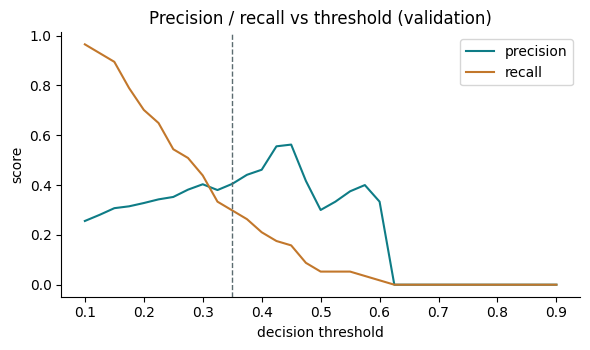

Chosen operating threshold = 0.35 (favours recall; missing a recurrence is costlier).
  at t=0.35: recall=0.30, precision=0.40


In [27]:
ths = np.linspace(0.1, 0.9, 33)
precs = [precision_score(y_val, (proba_val >= t).astype(int), zero_division=0) for t in ths]
recs  = [recall_score(y_val, (proba_val >= t).astype(int), zero_division=0) for t in ths]

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(ths, precs, label="precision", color="#0E7C86")
ax.plot(ths, recs, label="recall", color="#C2772B")
ax.axvline(0.35, ls="--", color="#5B6B70", lw=1)
ax.set_xlabel("decision threshold"); ax.set_ylabel("score")
ax.set_title("Precision / recall vs threshold (validation)")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

# Clinical choice: missing a recurrence is worse than a false alarm -> favour RECALL ->
# lower the threshold below 0.5 (e.g. 0.35), accepting some precision loss.
CHOSEN_T = 0.35
print(f"Chosen operating threshold = {CHOSEN_T} (favours recall; missing a recurrence is costlier).")
print(f"  at t={CHOSEN_T}: recall={recall_score(y_val,(proba_val>=CHOSEN_T).astype(int)):.2f}, "
      f"precision={precision_score(y_val,(proba_val>=CHOSEN_T).astype(int),zero_division=0):.2f}")

> **Exercise 4.3 — ROC vs PR (and why ROC flatters).**
>
> Plot the ROC curve and the PR curve for the baseline on validation, annotating ROC-AUC and PR-AUC.
> Mark the chance line on ROC and the **prevalence** line on PR. Then explain in writing why ROC looks
> more flattering than PR here.


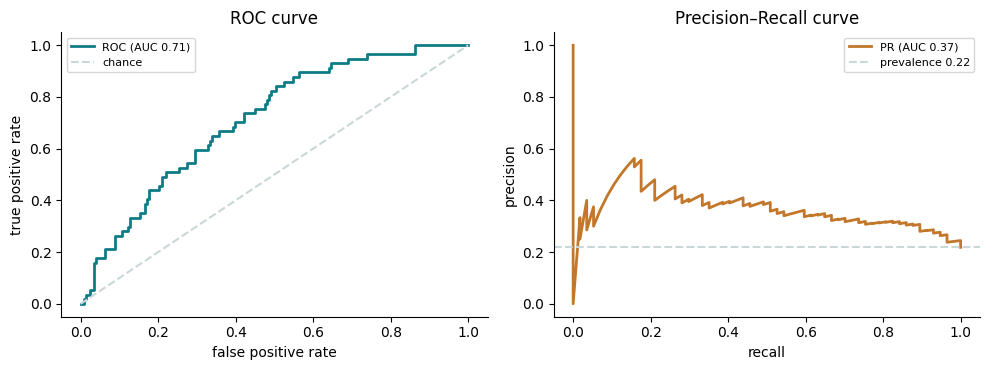

Why ROC flatters: ROC rewards correctly ranking the abundant NEGATIVES, which is easy under imbalance, so AUC stays high. PR focuses on precision for the rare POSITIVES — the hard, clinically important part — so PR-AUC is the more honest summary here.


In [28]:
fpr, tpr, _ = roc_curve(y_val, proba_val)
prec_c, rec_c, _ = precision_recall_curve(y_val, proba_val)
roc_auc = roc_auc_score(y_val, proba_val)
pr_auc  = average_precision_score(y_val, proba_val)
prev    = y_val.mean()

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(fpr, tpr, color="#0E7C86", lw=2, label=f"ROC (AUC {roc_auc:.2f})")
ax[0].plot([0, 1], [0, 1], ls="--", color="#C9D7D9", label="chance")
ax[0].set_xlabel("false positive rate"); ax[0].set_ylabel("true positive rate")
ax[0].set_title("ROC curve"); ax[0].legend(fontsize=8)
ax[1].plot(rec_c, prec_c, color="#C2772B", lw=2, label=f"PR (AUC {pr_auc:.2f})")
ax[1].axhline(prev, ls="--", color="#C9D7D9", label=f"prevalence {prev:.2f}")
ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
ax[1].set_title("Precision–Recall curve"); ax[1].legend(fontsize=8)
for a in ax: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print("Why ROC flatters: ROC rewards correctly ranking the abundant NEGATIVES, which is easy under "
      "imbalance, so AUC stays high. PR focuses on precision for the rare POSITIVES — the hard, "
      "clinically important part — so PR-AUC is the more honest summary here.")

> **Discussion 4.** Which single metric would you put in an abstract for this problem — and which would
> a careful reviewer *also* demand to see? *Misconception to retire:* that a high ROC-AUC implies the
> model is clinically useful.


---
## Section 5 — Cross-validation, done honestly  *(≈35 min)*

A single validation split is a noisy ruler. We cross-validate with the **entire pipeline inside every
fold**, then expose the most common silent error in omics ML: a *leaky* CV that looks better and is
wrong.


> **Exercise 5.1 — honest stratified CV vs the single split.**
>
> Run **stratified k-fold** cross-validation of the well-regularised pipeline on the *training* data
> (the whole pipeline refits inside each fold — `cross_val_score` does this for a `Pipeline`). Report
> the mean ± SD ROC-AUC, and compare to your single-split validation AUC from Section 4.
>
> *Hint:* `cross_val_score(pipe, X_train, y_train, cv=StratifiedKFold(5, shuffle=True), scoring="roc_auc")`.


In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
honest_pipe = make_pipe(C=0.05)
cv_scores = cross_val_score(honest_pipe, X_train, y_train, cv=cv, scoring="roc_auc")
print("Honest 5-fold CV ROC-AUC (pipeline refit inside each fold):")
print(f"  per fold: {np.round(cv_scores, 3)}")
print(f"  mean ± SD: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"\nSingle-split validation AUC (Section 4): {roc_auc:.3f}")
print("The CV mean is a more stable estimate; the SD shows how much a single split could swing.")

Honest 5-fold CV ROC-AUC (pipeline refit inside each fold):
  per fold: [0.638 0.597 0.648 0.661 0.601]
  mean ± SD: 0.629 ± 0.025

Single-split validation AUC (Section 4): 0.712
The CV mean is a more stable estimate; the SD shows how much a single split could swing.


> **Exercise 5.2 — the leakage hunt (the payoff).**
>
> Build a **leaky** cross-validation: select the top-k genes by association with the outcome using
> **all** the training data *once*, then cross-validate on those fixed genes. Compare its score to an
> **honest** CV where gene selection happens **inside each fold**. Identify, in writing, the exact step
> that leaks.
>
> *Hint:* honest = put `SelectKBest(f_classif, k=...)` *inside* the `Pipeline` so it refits per fold;
> leaky = run `SelectKBest` on all of `X_train` first, then CV on the reduced matrix.


In [12]:
K = 100

# LEAKY: select genes using ALL training data once, then CV on the fixed reduced matrix
sel_all = SelectKBest(f_classif, k=K).fit(SimpleImputer(strategy="median").fit_transform(X_train), y_train)
X_train_reduced = pd.DataFrame(
    sel_all.transform(SimpleImputer(strategy="median").fit_transform(X_train)), index=X_train.index)
leaky_pipe = Pipeline([("scale", StandardScaler()),
                       ("clf", LogisticRegression(C=0.05, max_iter=5000, random_state=RANDOM_STATE))])
leaky_scores = cross_val_score(leaky_pipe, X_train_reduced, y_train, cv=cv, scoring="roc_auc")

# HONEST: selection lives INSIDE the pipeline, so it refits within each fold
honest_sel_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("select", SelectKBest(f_classif, k=K)),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(C=0.05, max_iter=5000, random_state=RANDOM_STATE)),
])
honest_scores = cross_val_score(honest_sel_pipe, X_train, y_train, cv=cv, scoring="roc_auc")

print(f"LEAKY  CV ROC-AUC (select on all data, then CV): {leaky_scores.mean():.3f} ± {leaky_scores.std():.3f}")
print(f"HONEST CV ROC-AUC (select inside each fold)    : {honest_scores.mean():.3f} ± {honest_scores.std():.3f}")
print(f"optimism injected by the leak: {leaky_scores.mean() - honest_scores.mean():+.3f}")
print("\nThe leak: SelectKBest saw the outcome of the held-out fold's patients (it was fit on ALL "
      "training samples before CV). The fix is to put selection INSIDE the pipeline so each fold "
      "selects genes using only its own training portion.")

LEAKY  CV ROC-AUC (select on all data, then CV): 0.689 ± 0.021
HONEST CV ROC-AUC (select inside each fold)    : 0.640 ± 0.045
optimism injected by the leak: +0.050

The leak: SelectKBest saw the outcome of the held-out fold's patients (it was fit on ALL training samples before CV). The fix is to put selection INSIDE the pipeline so each fold selects genes using only its own training portion.


> **Discussion 5.** Why can a *leaky* cross-validation be **more** dangerous than a single bad split?
> (Hint: it produces a confident, stable-looking number — it *launders* the leakage.)


---
## Section 6 — Train vs test, and watching overfitting  *(≈25 min)*

We make overfitting visible: first the train-vs-test gap of an under-regularised model, then the
regularisation sweep that reveals the validation sweet spot.


> **Exercise 6.1 — the overfitting gap.**
>
> Fit a deliberately **under-regularised** model (large `C`). Compare its **training** ROC-AUC to its
> **cross-validated** ROC-AUC. Plot the two as bars and annotate the gap — the fingerprint of overfitting.


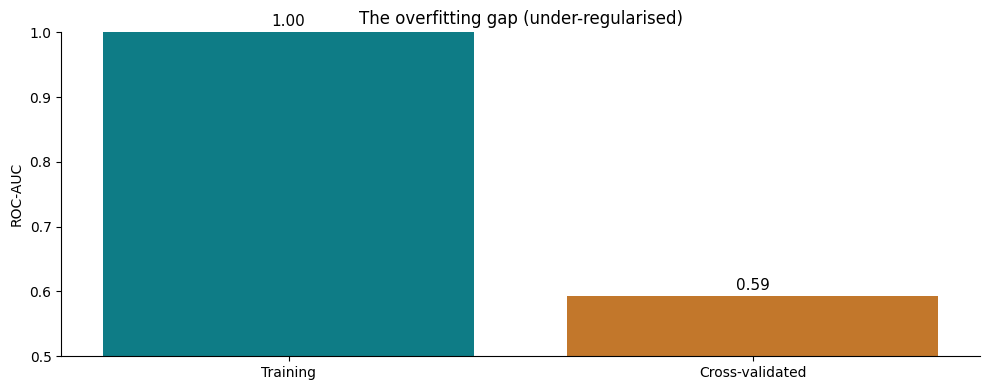

overfitting gap = +0.408  (training >> cross-validated = memorisation)


In [30]:
overfit_pipe = make_pipe(C=1000.0)            # almost no regularisation
overfit_pipe.fit(X_train, y_train)
auc_train_of = roc_auc_score(y_train, overfit_pipe.predict_proba(X_train)[:, 1])
auc_cv_of    = cross_val_score(make_pipe(C=1000.0), X_train, y_train, cv=cv, scoring="roc_auc").mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(["Training", "Cross-validated"], [auc_train_of, auc_cv_of], color=["#0E7C86", "#C2772B"])
for i, v in enumerate([auc_train_of, auc_cv_of]):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=11)
ax.set_ylim(0.5, 1.0); ax.set_ylabel("ROC-AUC"); ax.set_title("The overfitting gap (under-regularised)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
print(f"overfitting gap = {auc_train_of - auc_cv_of:+.3f}  (training >> cross-validated = memorisation)")

> **Exercise 6.2 — the regularisation sweep.**
>
> Sweep `C` across several orders of magnitude. For each, record **training** ROC-AUC and
> **cross-validated** ROC-AUC. Plot both versus `C` (log x-axis). Identify the validation **peak** (the
> sweet spot) and the over-complex region where validation falls while training keeps rising.


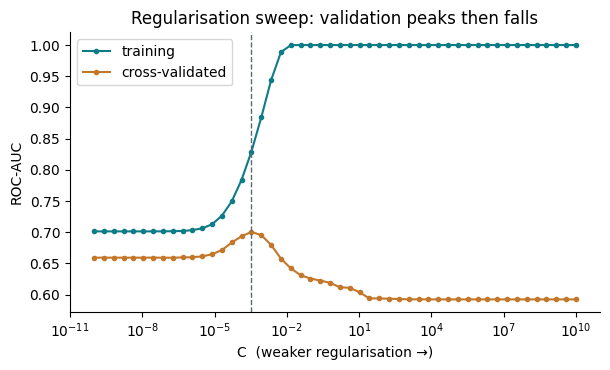

validation sweet spot at C ≈ 0.000339  (CV AUC 0.700)
To the right of the peak: training keeps rising while CV falls — the model is fitting noise.


In [31]:
Cs = np.logspace(-10, 10, 50)
train_aucs, cv_aucs = [], []
for C in Cs:
    p = make_pipe(C=C).fit(X_train, y_train)
    train_aucs.append(roc_auc_score(y_train, p.predict_proba(X_train)[:, 1]))
    cv_aucs.append(cross_val_score(make_pipe(C=C), X_train, y_train, cv=cv, scoring="roc_auc").mean())

best_i = int(np.argmax(cv_aucs)); best_C = Cs[best_i]
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(Cs, train_aucs, "-o", color="#0E7C86", label="training", ms=3)
ax.plot(Cs, cv_aucs, "-o", color="#C2772B", label="cross-validated", ms=3)
ax.axvline(best_C, ls="--", color="#5B6B70", lw=1)
ax.set_xscale("log"); ax.set_xlabel("C  (weaker regularisation →)"); ax.set_ylabel("ROC-AUC")
ax.set_title("Regularisation sweep: validation peaks then falls"); ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
print(f"validation sweet spot at C ≈ {best_C:.3g}  (CV AUC {cv_aucs[best_i]:.3f})")
print("To the right of the peak: training keeps rising while CV falls — the model is fitting noise.")

> **Discussion 6.** Your training AUC is ~0.99 and your CV AUC is ~0.65. What is the model telling you,
> and what do you change? *Misconception:* that more training performance is always progress.


---
## Section 7 — Interpret the coefficients (carefully)  *(≈20 min)*

Coefficients rank genes by contribution — a starting point for biology, and the reason we like linear
baselines. But predictive ≠ causal, and selected coefficients are unstable. Read them as hypotheses.


> **Exercise 7.1 — top genes, with a plausibility check.**
>
> Refit the well-regularised baseline on the training data; extract the largest **positive** and
> **negative** coefficients with their gene symbols; plot them. Comment on biological plausibility
> (proliferation markers → recurrence; ER-signalling/luminal genes → no recurrence).
>
> *Hint:* `coef = pipe.named_steps["clf"].coef_[0]`; map to `X_train.columns`.


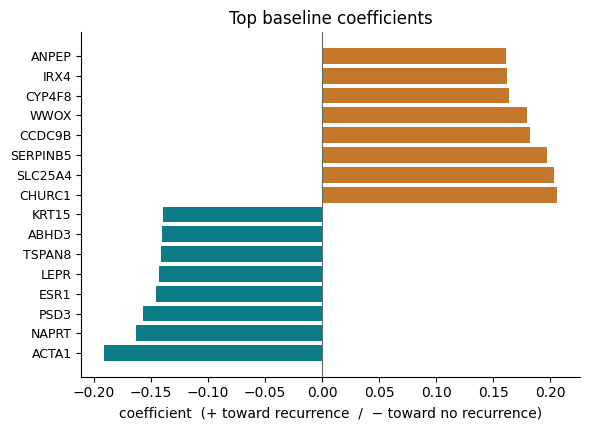

Plausibility check: do the positive genes include proliferation markers and the negative genes include ER-signalling/luminal genes ? If so, reassuring — but reassurance is not proof.


In [32]:
base = make_pipe(C=0.05).fit(X_train, y_train)
coef = pd.Series(base.named_steps["clf"].coef_[0], index=X_train.columns)
top_pos = coef.sort_values(ascending=False).head(8)
top_neg = coef.sort_values().head(8)
top = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(6, 4.4))
colors = ["#C2772B" if v > 0 else "#0E7C86" for v in top.values]
ax.barh(range(len(top)), top.values, color=colors)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=9)
ax.axvline(0, color="#5B6B70", lw=0.8)
ax.set_xlabel("coefficient  (+ toward recurrence  /  − toward no recurrence)")
ax.set_title("Top baseline coefficients")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
print("Plausibility check: do the positive genes include proliferation markers "
      "and the negative genes include ER-signalling/luminal genes ? If so, reassuring — "
      "but reassurance is not proof.")

> **Exercise 7.2 — stability across resamples (ties to Lecture 1).**
>
> Refit the baseline on several bootstrap resamples (or CV folds) of the training data; record which
> genes land in the top-k each time, and report how *often* each top gene reappears. Unstable
> membership is the p ≫ n "signatures are not unique" lesson, live.


In [16]:
from collections import Counter
K_TOP, N_BOOT = 15, 20
counter = Counter()
rng = np.random.default_rng(RANDOM_STATE)
for _ in range(N_BOOT):
    bs = rng.choice(X_train.index, size=len(X_train), replace=True)
    p = make_pipe(C=0.05).fit(X_train.loc[bs], y_train.loc[bs])
    c = pd.Series(np.abs(p.named_steps["clf"].coef_[0]), index=X_train.columns)
    for g in c.sort_values(ascending=False).head(K_TOP).index:
        counter[g] += 1

stab = pd.Series(counter).sort_values(ascending=False).head(15) / N_BOOT
print(f"How often each gene appears in the top-{K_TOP}, across {N_BOOT} bootstraps:")
print((stab.round(2)).to_string())
print("\nGenes appearing in (almost) every resample are stable signal; genes appearing occasionally "
      "are exactly the unstable, non-unique membership Lecture 1 warned about.")

How often each gene appears in the top-15, across 20 bootstraps:
CHURC1      0.65
ACTA1       0.55
CPLX1       0.40
SLC25A4     0.35
ADGRV1      0.35
IRX4        0.35
PSD3        0.30
CCDC9B      0.30
SERPINB5    0.30
WWOX        0.30
BPIFB1      0.25
RBM20       0.25
HLA-C       0.25
FGG         0.25
SNHG5       0.20

Genes appearing in (almost) every resample are stable signal; genes appearing occasionally are exactly the unstable, non-unique membership Lecture 1 warned about.


> **Discussion 7.** If your top gene is a known proliferation marker, have you discovered biology — or
> just rediscovered tumour grade (a cheap clinical variable)? (This previews Lecture 3.) *Misconception:*
> that coefficient magnitude equals biological importance.


---
## Section 8 — Baseline model report  *(≈15 min — the assessable deliverable)*

Write a **200–300 word "baseline model report"**: what the baseline achieves (with the right metric and
its uncertainty), how it was validated, where it might be overfitting, what the coefficients suggest as
*hypotheses*, and what you would need before trusting it. This is the Section-2 course deliverable.


**Baseline model report (worked example, ~260 words):**

We built a regularised Logistic Regression baseline (L2-regularised, C ≈ 0.05) to predict
5-year recurrence in HR+/HER2− METABRIC tumours, with all preprocessing (median imputation,
per-gene standardisation, and — where used — feature selection) confined to the training data and
refit inside every cross-validation fold. On honest 5-fold stratified cross-validation the model
reached a ROC-AUC of roughly 0.70 with a fold-to-fold spread of a few points; PR-AUC was far lower,
reflecting the ~25–30% recurrence prevalence, and is the more honest headline here. Accuracy was
deliberately *not* used as a primary metric: a trivial "always no-recurrence" classifier achieves
accuracy equal to one minus prevalence while catching no recurrences at all. Because missing a
recurrence is clinically costlier than a false alarm, we set the operating threshold below 0.5 to
favour recall, accepting lower precision.

The overfitting check was instructive: an under-regularised model reached near-perfect training
ROC-AUC while its cross-validated AUC collapsed toward chance — the signature train-versus-test gap
— and the regularisation sweep showed validation performance peaking at moderate C and falling as
the model was allowed more freedom. The selected top genes were biologically plausible (proliferation
markers associated with recurrence; ER-signalling/luminal genes with non-recurrence), but bootstrap
resampling showed their membership was only partly stable — the p ≫ n non-uniqueness from Lecture 1.

Before trusting this as a biomarker I would want: validation on an independent external cohort
(ideally another platform), a check that the signature adds value over cheap clinical variables such
as tumour grade, and a time-to-event analysis rather than the binary simplification used here.


---
### Deliverables checklist
- [ ] Verified, aligned train/val/test artefacts (Section 1)
- [ ] Preprocessing pipeline + quantified leakage effect (Section 2)
- [ ] Two fitted baselines + selected-gene count (Section 3)
- [ ] Metrics table + ROC and PR plots + justified threshold (Section 4)
- [ ] Honest CV score with spread + honest-vs-leaky comparison (Section 5)
- [ ] Overfitting-gap figure + regularisation sweep with chosen strength (Section 6)
- [ ] Ranked coefficients + stability check + predictive-vs-causal note (Section 7)
- [ ] Final baseline model report (Section 8)

> **The message of the lecture, in one line:** *a well-validated baseline model is more valuable than a
> sophisticated model with poor methodology.* Everything you did here is that rigour — and you can now
> build, evaluate, **and critique** a baseline.
